In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch.utils.data import Dataset, DataLoader, random_split

## Loading datasets

In [9]:
network_normal_df = pd.read_csv('dataset/Network datatset/csv/normal.csv')
network_attack_1_df = pd.read_csv('dataset/Network datatset/csv/attack_1.csv')
network_attack_2_df = pd.read_csv('dataset/Network datatset/csv/attack_2.csv')
network_attack_3_df = pd.read_csv('dataset/Network datatset/csv/attack_3.csv')

network_attack_1_df.columns = network_normal_df.columns
network_attack_2_df.columns = network_normal_df.columns
network_attack_3_df.columns = network_normal_df.columns

In [3]:
network_df = pd.concat([network_normal_df, network_attack_1_df, network_attack_2_df, network_attack_3_df], ignore_index=True)

In [4]:
display(network_df)

,Time,mac_s,mac_d,ip_s,ip_d,sport,dport,proto,flags,size,modbus_fn,n_pkt_src,n_pkt_dst,modbus_response,label_n,label
0,2021-04-09 11:30:52.716203,74:46:a0:bd:a7:1b,fa:00:bc:90:d7:fa,84.3.251.20,84.3.251.103,61516.0,502.0,Modbus,11000.0,66,Read Holding Registers,0.0,0.0,NaN,0,normal
1,2021-04-09 11:30:52.716499,fa:00:bc:90:d7:fa,74:46:a0:bd:a7:1b,84.3.251.103,84.3.251.20,502.0,61516.0,Modbus,11000.0,65,Read Holding Registers Response,0.0,0.0,[0],0,normal
2,2021-04-09 11:30:52.717334,74:46:a0:bd:a7:1b,e6:3f:ac:c9:a8:8c,84.3.251.20,84.3.251.101,61515.0,502.0,Modbus,11000.0,66,Read Holding Registers,1.0,0.0,NaN,0,normal
3,2021-04-09 11:30:52.717624,e6:3f:ac:c9:a8:8c,74:46:a0:bd:a7:1b,84.3.251.101,84.3.251.20,502.0,61515.0,Modbus,11000.0,65,Read Holding Registers Response,0.0,1.0,[0],0,normal
4,2021-04-09 11:30:52.717952,00:80:f4:03:fb:12,74:46:a0:bd:a7:1b,84.3.251.18,84.3.251.20,502.0,61514.0,Modbus,11000.0,64,Read Coils Response,0.0,2.0,[0],0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24306709,2021-04-09 20:03:04.789873,74:46:a0:bd:a7:1b,e6:3f:ac:c9:a8:8c,84.3.251.20,84.3.251.101,58140.0,502.0,Modbus,11000.0,66,Read Holding Registers,50.0,15.0,NaN,0,normal
24306710,2021-04-09 20:03:04.789876,74:46:a0:bd:a7:1b,fa:00:bc:90:d7:fa,84.3.251.20,84.3.251.103,57988.0,502.0,Modbus,11000.0,66,Read Coils Request,50.0,15.0,NaN,0,normal
24306711,2021-04-09 20:03:04.790308,e6:3f:ac:c9:a8:8c,74:46:a0:bd:a7:1b,84.3.251.101,84.3.251.20,502.0,58140.0,Modbus,11000.0,65,Read Holding Registers Response,15.0,49.0,[433],0,normal
24306712,2021-04-09 20:03:04.790472,fa:00:bc:90:d7:fa,74:46:a0:bd:a7:1b,84.3.251.103,84.3.251.20,502.0,57988.0,Modbus,11000.0,64,Read Coils Response,15.0,50.0,[0],0,normal


In [2]:
phys_normal_df = pd.read_csv('dataset/Physical Dataset/phy_norm.csv', delimiter='\t')
phys_attack_1_df = pd.read_csv('dataset/Physical Dataset/phy_att_1.csv', delimiter='\t')
phys_attack_2_df = pd.read_csv('dataset/Physical Dataset/phy_att_2.csv', delimiter='\t')
phys_attack_3_df = pd.read_csv('dataset/Physical Dataset/phy_att_3.csv', delimiter='\t')

phys_attack_1_df.columns = phys_normal_df.columns
phys_attack_2_df.columns = phys_normal_df.columns
phys_attack_3_df.columns = phys_normal_df.columns

NameError: name 'pd' is not defined

In [6]:
physical_df = pd.concat([phys_normal_df, phys_attack_1_df, phys_attack_2_df, phys_attack_3_df])

In [7]:
display(physical_df)

,Time,Tank_1,Tank_2,Tank_3,Tank_4,Tank_5,Tank_6,Tank_7,Tank_8,Pump_1,...,Valv_15,Valv_16,Valv_17,Valv_18,Valv_19,Valv_20,Valv_21,Valv_22,Label_n,Label
0,09/04/2021 11:30:50,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
1,09/04/2021 11:30:51,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
2,09/04/2021 11:30:52,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
3,09/04/2021 11:30:53,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
4,09/04/2021 11:30:54,0,0,0,0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,09/04/2021 20:03:01,3,178,7,484,313,443,64,0,True,...,True,False,False,False,False,True,False,False,0,normal
1250,09/04/2021 20:03:02,3,230,8,471,308,443,64,0,True,...,True,False,False,False,False,True,False,False,0,normal
1251,09/04/2021 20:03:03,3,261,7,462,304,442,80,0,True,...,True,False,False,False,False,True,False,False,0,normal
1252,09/04/2021 20:03:04,3,288,7,449,299,442,88,0,True,...,True,False,False,False,False,True,False,False,0,normal


## Exploratory Analysis
### Network-based attacks

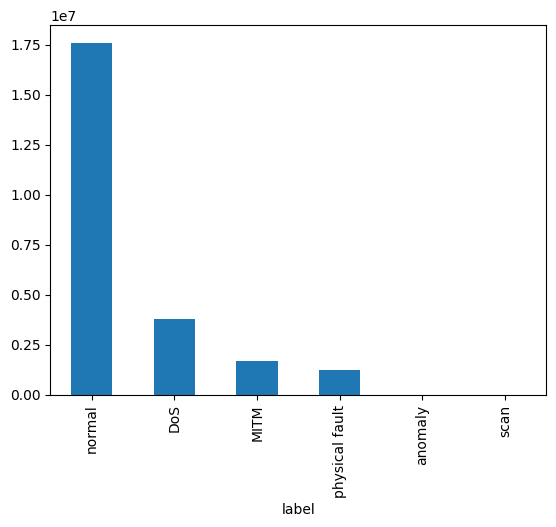

In [8]:
network_df.label.value_counts().plot(kind='bar')
plt.show()
plt.close()

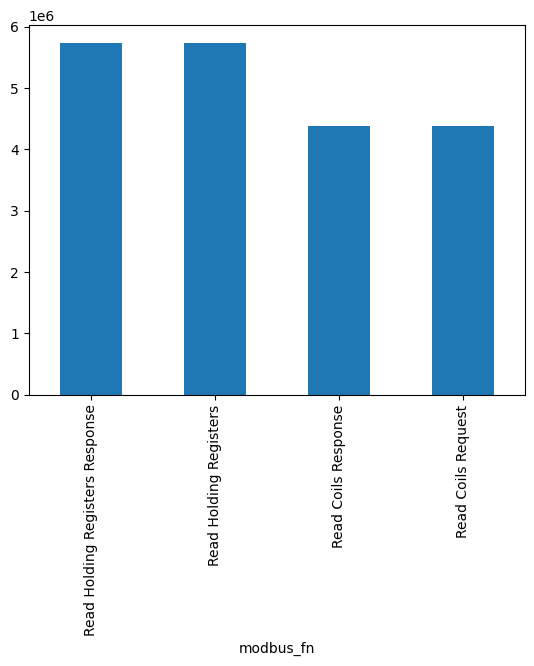

In [9]:
network_df.modbus_fn.value_counts().plot(kind='bar')
plt.show()
plt.close()

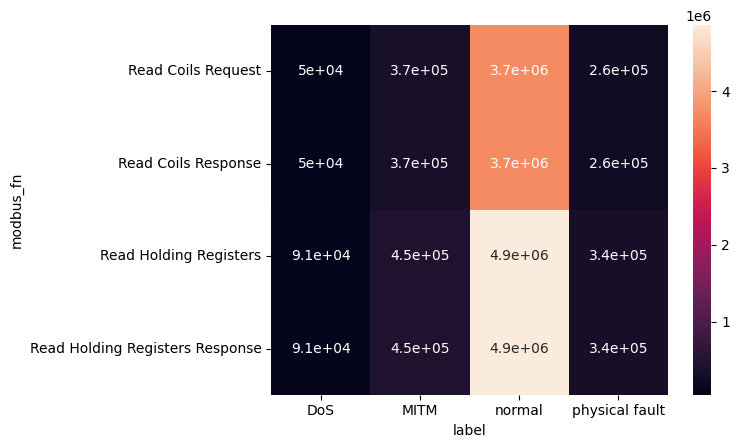

In [10]:
sns.heatmap(
    pd.pivot_table(network_df, values='label_n', index='modbus_fn', columns='label', aggfunc='count', fill_value=0),
    annot=True
)
plt.show()
plt.close()

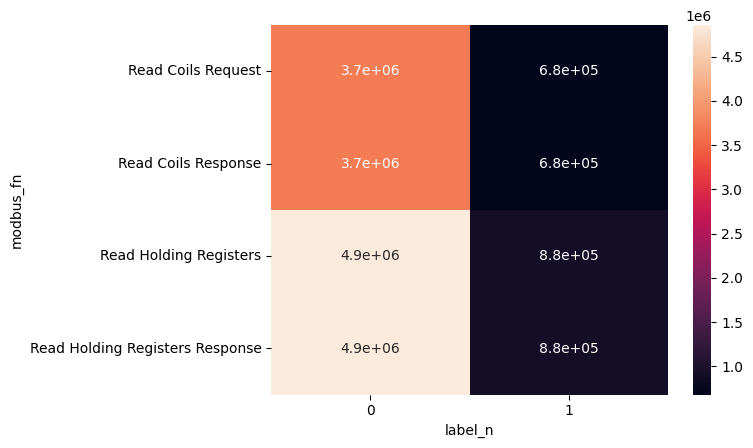

In [11]:
sns.heatmap(
    pd.pivot_table(network_df, values='label', index='modbus_fn', columns='label_n', aggfunc='count', fill_value=0),
    annot=True
)
plt.show()
plt.close()

## Model creation
### Network-based attacks
#### Attack detection

In [12]:
def get_one_hot_encoding(dataframe):
    if dataframe is None:
        return None
    return pd.get_dummies(dataframe)

def get_is_attacked_data(dataframe):
    res = get_one_hot_encoding(dataframe.drop(['Time', 'modbus_response', 'label'], axis=1))
    res['modbus_response'] = dataframe['modbus_response']
    res.loc[res['modbus_response'].notnull(), 'modbus_response'] = res.loc[res['modbus_response'].notnull(), 'modbus_response'].str[1:-1].astype(int)
    return res

In [13]:
class NetworkIsAttackedDataset(Dataset):
    def __init__(self, df):
        self.df = get_is_attacked_data(df)
        self.features = self.df.drop(['label_n'], axis=1).values
        self.label = df.label_n.values
    
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return torch.tensor(self.features[idx]), torch.tensor(self.label[idx])

In [14]:
network_is_attacked_dataset = NetworkIsAttackedDataset(network_df)

train_size = int(0.7 * len(network_is_attacked_dataset))
val_size = int(0.15 * len(network_is_attacked_dataset))
test_size = len(network_is_attacked_dataset) - train_size - val_size

train_net_is_attacked_dataset, val_net_is_attacked_dataset, test_net_is_attacked_dataset = random_split(network_is_attacked_dataset, [train_size, val_size, test_size])

train_net_is_attacked_loader = DataLoader(train_net_is_attacked_dataset, batch_size=2, shuffle=True)
val_net_is_attacked_loader = DataLoader(val_net_is_attacked_dataset, batch_size=2, shuffle=False)
test_net_is_attacked_loader = DataLoader(test_net_is_attacked_dataset, batch_size=2, shuffle=False)